## Customer Churn


How likely is the customer going to leave the product and they will be rated accordingly.we will classify into binary classification 
Classifcation model =g(x)~~ y
Y {0,1} means 0 is negative 1 is positive: 0 states no Churn and 1 states Churn 
Output of model would be between 0 &1 stating the likelyhood of Churn

Data from : https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [162]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
%matplotlib inline


In [163]:
#data='https://www.kaggle.com/datasets/blastchar/telco-customer-churn?select=WA_Fn-UseC_-Telco-Customer-Churn.csv'
#!wget $data -o customer.csv

In [164]:
df=pd.read_csv("customer.csv")
df.head(5)

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [165]:

df.columns=df.columns.str.lower().str.replace(" ","_")

categorical_cloumns=list(df.dtypes[df.dtypes=='str'].index)

for c in categorical_cloumns:
    df[c]=df[c].str.lower().str.replace(" ","_")

df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [166]:
df.totalcharges=pd.to_numeric(df.totalcharges,errors='coerce')
df.totalcharges=df.totalcharges.fillna(0)

df['churn'] = df['churn'].map({'yes': 1, 'no': 0}).astype(int)


### Setting Up Validation framework

In [167]:
from sklearn.model_selection import train_test_split


# intially divide data into train and test where test is 20% remining 80% is train
df_full_train,df_test=train_test_split(df,test_size=0.20,random_state=1)

len(df_full_train) ,len(df_test)

(5634, 1409)

In [168]:
## now splitting full train (80%) into training and validation sets 
# splitting 80% to 20 60 and 20% out of 20/80 is 0.25
df_train,df_val=train_test_split(df_full_train,test_size=0.25,random_state=1)

len(df_train) , len(df_val),len(df_test)

(4225, 1409, 1409)

In [169]:
df_train=df_train.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)

In [170]:
y_train=df_train.churn.values
y_test=df_test.churn.values
y_val=df_val.churn.values

In [171]:
del df_train['churn']
del df_test['churn']
del df_val['churn']

#### EDA

In [172]:
df_full_train=df_full_train.reset_index(drop=True)
df_full_train.head()

df_full_train.isnull().sum()

df_full_train.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [173]:
global_churn_rate=df_full_train.churn.mean()
global_churn_rate

np.float64(0.26996805111821087)

In [174]:
df_full_train.dtypes

numerical=['tenure','monthlycharges','totalcharges']

categorical=[ 'gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

df_full_train[categorical].nunique()



gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

### Feature Importance & Churn Rate

In [175]:
df_female_churn=df_full_train[df_full_train.gender=='female'].churn.mean()
df_male_churn=df_full_train[df_full_train.gender=='male'].churn.mean()

df_female_churn,df_male_churn

(np.float64(0.27682403433476394), np.float64(0.2632135306553911))

In [176]:
df_full_train.partner.value_counts()

churn_with_partner=df_full_train[df_full_train.partner=='yes'].churn.mean()
churn_without_partner=df_full_train[df_full_train.partner=='no'].churn.mean()

churn_with_partner,churn_without_partner

(np.float64(0.20503330866025166), np.float64(0.3298090040927694))

In [177]:
print(global_churn_rate-df_female_churn)
print(global_churn_rate-df_male_churn)      
print(global_churn_rate-churn_with_partner)  ## this is significant
print(global_churn_rate-churn_without_partner)


-0.006855983216553063
0.006754520462819769
0.06493474245795922
-0.05984095297455855


In [178]:
## to convert to df not series we used .agg() method
df_group=df_full_train.groupby('gender').churn.agg(['mean','count'])
df_group["diff"]=df_group['mean']-global_churn_rate
df_group["risk"]=df_group['mean']/global_churn_rate

df_group

,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


##Feature Importance :Mutual Information

In [179]:
from sklearn.metrics import mutual_info_score

mutual_info_score(df_full_train.churn,df_full_train.gender) ## less significant on churn

0.0001174846211139946

In [180]:
mutual_info_score(df_full_train.churn,df_full_train.contract) ## significant on churn

0.0983203874041556

In [181]:
mutual_info_score(df_full_train.churn,df_full_train.partner) ## significant than gender on churn

0.009967689095399745

In [182]:
### we can use a method to apply this across variables 

def mutual_info_score_churn(series):
    return mutual_info_score(series,df_full_train.churn)

df_full_train[categorical].apply(mutual_info_score_churn)

gender              0.000117
seniorcitizen       0.009410
partner             0.009968
dependents          0.012346
phoneservice        0.000229
multiplelines       0.000857
internetservice     0.055868
onlinesecurity      0.063085
onlinebackup        0.046923
deviceprotection    0.043453
techsupport         0.061032
streamingtv         0.031853
streamingmovies     0.031581
contract            0.098320
paperlessbilling    0.017589
paymentmethod       0.043210
dtype: float64

In [183]:
mi=df_full_train[categorical].apply(mutual_info_score_churn)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

### Feature Importance :Correlation

For numeric variables

In [184]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [185]:
## lets check it out

df_full_train[df_full_train['tenure']<2].churn.mean()

np.float64(0.6247464503042597)

In [186]:

df_full_train[(df_full_train['tenure']> 2) & (df_full_train['tenure']<12 )].churn.mean()

np.float64(0.4059003051881994)

In [187]:
df_full_train[df_full_train['tenure']>12].churn.mean() ## over the months the churn rate decreases

np.float64(0.17634908339788277)

### One Hot Encoding

In [188]:
from sklearn.feature_extraction import DictVectorizer

df_full_train[['gender','contract']].iloc[:10]

,gender,contract
0,male,two_year
1,female,one_year
2,male,two_year
3,male,one_year
4,male,one_year
5,female,month-to-month
6,male,two_year
7,male,month-to-month
8,male,month-to-month
9,female,month-to-month


In [189]:
dict=df_full_train[['gender','contract']].iloc[:10].to_dict(orient='records')
dict

[{'gender': 'male', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'one_year'},
 {'gender': 'male', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'one_year'},
 {'gender': 'male', 'contract': 'one_year'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'}]

In [190]:
dv=DictVectorizer(sparse=False)
dv.fit(dict)

dv.transform(dict)

array([[0., 0., 1., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 1.],
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.]])

In [191]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male'], dtype=object)

In [192]:
train_dicts=df_train[categorical+numerical].to_dict(orient='records')
dv=DictVectorizer(sparse=False)
#dv.fit(train_dicts)

x_train=dv.fit_transform(train_dicts)

In [193]:
val_dicts=df_val[categorical+numerical].to_dict(orient='records')
dv.fit(val_dicts)
x_val=dv.transform(val_dicts)

##Logisctic Regression

In [194]:
## ITS similar to Linear Regression however linear regression's output is any real number from -ive to +ive infinity
## Logistics regression usses sigmoid (w0+w1x1...) to predict a number between 0 & 1 

def sigmoid(z): ## z is input to the Sigmoid
    return 1/(1+np.exp(-z)) ## exponent of -z

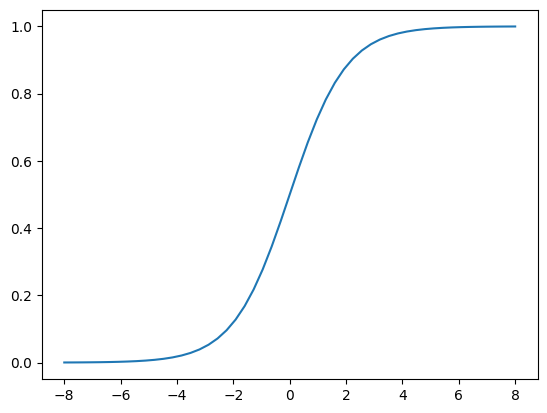

In [195]:
## lests test
z=np.linspace(-8,8,51)
sigmoid(z)
plt.plot(z,sigmoid(z))

In [196]:
def linear_regression(xi):
    result=w0

    for j in len(xi):
        result=result+xi[j] * wi[j]
    return result

In [197]:
def logistic_regression(xi):
    score=w0

    for j in len(xi):
        score= sigmoid(scoret+xi[j] * wi[j])
        result=sigmoid(score)
    return result

## Training Logistic Regression with SKLEARN

In [198]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model.fit(x_train,y_train)
model.coef_[0].round(3) ## weights
model.intercept_[0]

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


np.float64(-0.10913176644533581)

In [199]:
model.predict(x_train)## hard prediction either 1 or 0
y_pred=model.predict_proba(x_val)[:,1]## probability first col represents the probability of o and second probaility of 1
y_pred

array([0.00900149, 0.20409034, 0.21172505, ..., 0.13635079, 0.79942379,
       0.83708596], shape=(1409,))

In [200]:
churn_decision=(y_pred>=0.5)
churn_decision

array([False, False, False, ..., False,  True,  True], shape=(1409,))

In [201]:

(y_val==churn_decision).mean()

np.float64(0.8034066713981547)

In [202]:
df_pred=pd.DataFrame()
df_pred['probability']=y_pred
df_pred['prediction']=churn_decision.astype(int)
df_pred['actual']=y_val

In [203]:
df_pred['correct']=df_pred['prediction']==df_pred['actual']
df_pred

,probability,prediction,actual,correct
0,0.009001,0,0,True
1,0.204090,0,0,True
2,0.211725,0,0,True
3,0.542751,1,1,True
4,0.213315,0,0,True
...,...,...,...,...
1404,0.313144,0,0,True
1405,0.039347,0,1,False
1406,0.136351,0,0,True
1407,0.799424,1,1,True


In [204]:
df_val[churn_decision].customerid ## these are people who will receive an email as they are highly likely to churn

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 311, dtype: str

### Model Interpretation

In [205]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [206]:
model.coef_[0].round(3)

array([ 0.474, -0.175, -0.407, -0.03 , -0.078,  0.063, -0.089, -0.081,
       -0.034, -0.073, -0.335,  0.316, -0.089,  0.004, -0.258,  0.141,
        0.009,  0.063, -0.089, -0.081,  0.265, -0.089, -0.284, -0.231,
        0.123, -0.166,  0.058, -0.087, -0.032,  0.07 , -0.059,  0.141,
       -0.249,  0.215, -0.12 , -0.089,  0.102, -0.071, -0.089,  0.052,
        0.213, -0.089, -0.232, -0.071,  0.   ])

In [207]:
## zip combines both elements of lists like a from list a and 0 from from based on index
#zip((dv.get_feature_names_out(),model.coef_[0].round(3))
#test=zip(dv.get_feature_names_out(),model.coef_[0].round(3)) ## converting to dictionary

In [208]:
small=['contract','tenure','monthlycharges'] ### smaller model 
df_train[small].iloc[:2].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25}]

In [209]:
df_train_small=df_train[small].to_dict(orient='records')
df_val_small=df_val[small].to_dict(orient='records')
dv_small=DictVectorizer(sparse=False)
dv_small.fit(df_train_small)
dv_small.get_feature_names_out()







array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [210]:
x_train_small=dv_small.transform(df_train_small)
model_small=LogisticRegression()
model_small.fit(x_train_small,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [211]:
w0=model_small.intercept_[0]

zip(dv_small.get_feature_names_out(),model.coef_[0].round(3))

## Using Model

In [212]:
dict_full_train=df_full_train[categorical+numerical].to_dict(orient='records')
df_full_train[:3]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0


In [213]:
dv=DictVectorizer(sparse=False)
x_full_train=dv.fit_transform(dict_full_train)
y_full_train=df_full_train.churn.values
model=LogisticRegression()
model.fit(x_full_train,y_full_train)

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [215]:
## for test
dict_full_test=df_test[categorical+numerical].to_dict(orient='records')
x_test=dv.transform(dict_full_test)
y_pred=model.predict_proba(x_test)[:,1]

churn_decision=(y_pred>=0.5)
(churn_decision==y_test).mean()

np.float64(0.8147622427253371)

In [ ]:
customer=dict_full_test[10]
x_customer=dv.transform([customer])
model.predict_proba(x_customer) ## model says customer is not likely to churn its 49 %

array([[0.50204515, 0.49795485]])

In [ ]:
y_test[0] ## cross verifying the churn value is 0 :) he is not likely to churn

np.int64(0)

In [ ]:
customer=dict_full_test[-1]
x_customer=dv.transform([customer])
model.predict_proba(x_customer) ## model says customer is  likely to churn its  %65

array([[0.34533515, 0.65466485]])

In [ ]:
y_test[-1] ## cross verifying the churn value is 1 :) she is likely to churn we need to send her a promotional email

np.int64(1)